# Creating a Realistic Dataset from Multiple Surveys
We are going to create a realistic dataset that mimics the light curve shown in Figure 1 of https://arxiv.org/abs/2509.10601v1. We'll pull and merge Gaia DR3, CRTS, and ZTF DR23 light curves.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from functools import partial

import astropy
import astropy.units as u
import lsdb
import matplotlib.pyplot as plt
import nested_pandas as npd
import pandas as pd
from astropy import coordinates, time
from astroquery.gaia import Gaia
from crts_lc_fetch import get_crts_csv_data
print(f"{lsdb.__version__=}")

lsdb.__version__='0.6.8.dev11+g14197024e'


## Load in Gaia DR3

In [3]:
gaia_lc_t0 = astropy.time.Time("2010-01-01T00:00:00")

In [4]:
retrieval_type = "EPOCH_PHOTOMETRY"  # Options are: 'EPOCH_PHOTOMETRY', 'MCMC_GSPPHOT', 'MCMC_MSC', 'XP_SAMPLED', 'XP_CONTINUOUS', 'RVS', 'ALL'

data_structure = "INDIVIDUAL"  # Options are: 'INDIVIDUAL' or 'RAW'

data_release = "Gaia DR3"  # Options are: 'Gaia DR3' (default), 'Gaia DR2'

datalink = Gaia.load_data(
    ids=[3870752104863883264],
    data_release=data_release,
    retrieval_type=retrieval_type,
    data_structure=data_structure,
)

In [5]:
gaia_lc_df = (
    datalink["EPOCH_PHOTOMETRY-Gaia DR3 3870752104863883264.xml"][0].to_table().to_pandas()
)
print(gaia_lc_df.columns)
gaia_lc_df.head()

Index(['transit_id', 'g_transit_time', 'g_transit_flux',
       'g_transit_flux_error', 'g_transit_flux_over_error', 'g_transit_mag',
       'bp_obs_time', 'bp_flux', 'bp_flux_error', 'bp_flux_over_error',
       'bp_mag', 'rp_obs_time', 'rp_flux', 'rp_flux_error',
       'rp_flux_over_error', 'rp_mag', 'variability_flag_g_reject',
       'variability_flag_bp_reject', 'variability_flag_rp_reject',
       'g_other_flags', 'bp_other_flags', 'rp_other_flags',
       'rejected_by_photometry'],
      dtype='object')


,transit_id,g_transit_time,g_transit_flux,g_transit_flux_error,g_transit_flux_over_error,g_transit_mag,bp_obs_time,bp_flux,bp_flux_error,bp_flux_over_error,...,rp_flux_error,rp_flux_over_error,rp_mag,variability_flag_g_reject,variability_flag_bp_reject,variability_flag_rp_reject,g_other_flags,bp_other_flags,rp_other_flags,rejected_by_photometry
0,20161315636122951,1761.447751,841.717507,8.797137,95.680840,18.374451,1761.448066,498.043395,19.097970,26.078342,...,20.837691,27.661383,17.846087,False,False,False,1,0,0,False
1,20165407946227793,1761.521736,821.253149,5.457072,150.493362,18.401174,1761.522079,481.005309,25.537910,18.834951,...,28.236287,15.382051,18.153341,False,False,False,4194305,0,0,False
2,21350161997903704,NaN,NaN,NaN,NaN,NaN,1782.949758,564.052573,19.212816,29.358143,...,18.840056,29.369940,17.890432,True,False,False,8373247,0,0,True
3,21354254306022628,1783.023458,844.234341,6.861128,123.045990,18.371209,1783.023773,444.846601,19.407313,22.921597,...,20.602749,25.961678,17.927251,False,False,False,1,0,0,False
4,22925353792447639,1811.438839,855.902683,6.464051,132.409637,18.356306,1811.439154,587.376153,27.606811,21.276495,...,30.883706,18.991220,17.827190,False,False,False,1,0,0,False


## Format Data and Convert Units
We'll try to recreate the Gaia portion of Figure 1 in https://arxiv.org/pdf/2509.10601v1, which uses (normalized) flux

In [6]:
gaia_lc_df["g_transit_time"] += gaia_lc_t0.mjd
gaia_lc_df = gaia_lc_df.eval("g_transit_mag_error = 2.5 / g_transit_flux_over_error")
gaia_lc_df = gaia_lc_df.query(
    "variability_flag_g_reject == False and rejected_by_photometry == False"
)[
    [
        "g_transit_time",
        "g_transit_flux",
        "g_transit_flux_error",
        "g_transit_flux_over_error",
        "g_transit_mag",
        "g_transit_mag_error",
    ]
]

In [7]:
gaia_lc_df["g_normalized_flux"] = (
    gaia_lc_df["g_transit_flux"] / gaia_lc_df["g_transit_flux"].mean()
)
gaia_lc_df["g_normalized_flux_error"] = (
    gaia_lc_df["g_transit_flux_error"] / gaia_lc_df["g_transit_flux"].mean()
)
gaia_lc_df = gaia_lc_df.query("g_transit_mag_error < 3*g_transit_mag_error.median()")
# gaia_lc_pandas = gaia_lc_pandas.query('g_transit_mag_error < 0.09')
gaia_lc_df = gaia_lc_df.sort_values(by="g_transit_time").reset_index()

<Axes: xlabel='g_transit_time', ylabel='g_normalized_flux'>

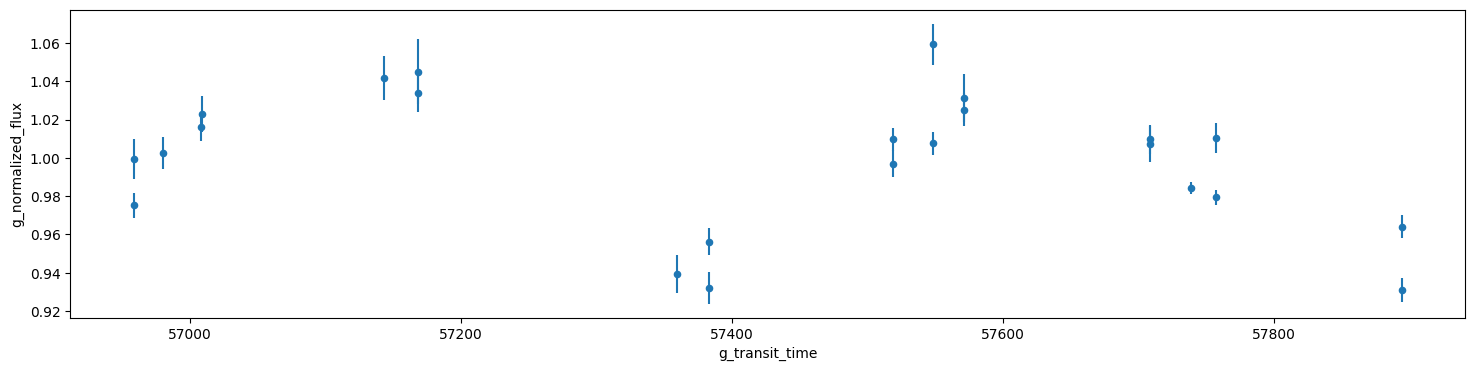

In [8]:
gaia_lc_df.plot(
    x="g_transit_time",
    y="g_normalized_flux",
    yerr="g_normalized_flux_error",
    kind="scatter",
    figsize=(18, 4),
)

### Pull from LSDB
We don't need this, but let's do it for consistency with ZTF.

In [9]:
gaia_lsdb = lsdb.open_catalog(
    "https://data.lsdb.io/hats/gaia_dr3/",
    columns=[
        "source_id",
        "ra",
        "dec",
    ],
)

In [10]:
gaia_lsdb.head()

,source_id,ra,dec
_healpix_29,,,
3121269471,4295806720,44.996155,0.005615
29153808338,38655544960,45.004978,0.01988
29640498453,34361129088,45.00432,0.021048
162211426005,309238066432,44.995037,0.038152
187874219371,343597448960,44.963896,0.043595


### Find the source we want

In [11]:
gaia_lsdb_filtered = gaia_lsdb.id_search({"source_id": 3870752104863883264}, fine=True)
c_gaia_lsdb_filtered = gaia_lsdb_filtered.compute()

Searching for source_id=3870752104863883264


In [12]:
c_gaia_lsdb_filtered = c_gaia_lsdb_filtered.rename(columns={"source_id": "id"})
c_gaia_lsdb_filtered.head()

,id,ra,dec
_healpix_29,,,
1935376064122701448,3870752104863883264,160.798045,11.397157


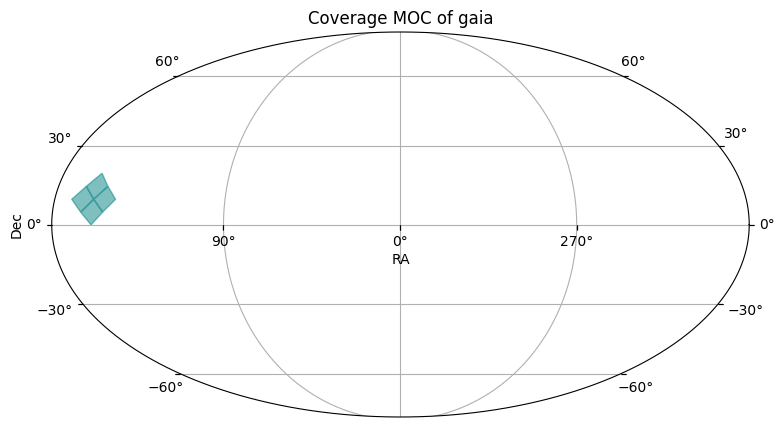

In [13]:
_ = gaia_lsdb_filtered.plot_coverage()

### Make a dataframe with an entry for each observation
We'll use this later to make a nested dataframe

In [14]:
gaia_lc_df["id"] =  0 #gf["id"].to_numpy().repeat(len(gaia_lc_pandas))
gaia_lc_df.head()

,index,g_transit_time,g_transit_flux,g_transit_flux_error,g_transit_flux_over_error,g_transit_mag,g_transit_mag_error,g_normalized_flux,g_normalized_flux_error,id
0,0,56958.447751,841.717507,8.797137,95.680840,18.374451,0.026129,0.999469,0.010446,0
1,1,56958.521736,821.253149,5.457072,150.493362,18.401174,0.016612,0.975169,0.006480,0
2,3,56980.023458,844.234341,6.861128,123.045990,18.371209,0.020318,1.002457,0.008147,0
3,4,57008.438839,855.902683,6.464051,132.409637,18.356306,0.018881,1.016312,0.007676,0
4,5,57008.512853,861.416482,7.845729,109.794312,18.349334,0.022770,1.022860,0.009316,0


### Change the format a bit more

In [15]:
gaia_lc_df["band"] = "g"
gaia_lc_df["survey"] = "gaia_dr3"
gaia_lc_df["survey_id"] = 3870752104863883264
gaia_lc_df["ra"] = c_gaia_lsdb_filtered["ra"].to_numpy().item()
gaia_lc_df["dec"] = c_gaia_lsdb_filtered["dec"].to_numpy().item()
gaia_df = gaia_lc_df.rename(
    columns={
        "g_transit_time": "mjd",
        "g_transit_flux": "flux",
        "g_transit_flux_error": "flux_error",
        "g_transit_mag": "mag",
        "g_transit_mag_error": "mag_error",
    }
).drop(
    columns=[
        "g_normalized_flux",
        "g_normalized_flux_error",
        "g_transit_flux_over_error",
        "index",
        "flux",
        "flux_error",
    ]
)
gaia_df.head()

,mjd,mag,mag_error,id,band,survey,survey_id,ra,dec
0,56958.447751,18.374451,0.026129,0,g,gaia_dr3,3870752104863883264,160.798045,11.397157
1,56958.521736,18.401174,0.016612,0,g,gaia_dr3,3870752104863883264,160.798045,11.397157
2,56980.023458,18.371209,0.020318,0,g,gaia_dr3,3870752104863883264,160.798045,11.397157
3,57008.438839,18.356306,0.018881,0,g,gaia_dr3,3870752104863883264,160.798045,11.397157
4,57008.512853,18.349334,0.022770,0,g,gaia_dr3,3870752104863883264,160.798045,11.397157


## Load ZTF from LSDB
We'll just grab a region around the Gaia target

In [16]:
from astropy import units as u
from astropy.coordinates import EarthLocation, SkyCoord
from astropy.time import Time


def helio_to_bary(coords, hjd, obs_name):
    helio = Time(hjd, scale="utc", format="mjd")
    obs = EarthLocation.of_site(obs_name)
    star = SkyCoord(coords)  # , unit=(u.hour, u.deg))
    ltt = helio.light_travel_time(star, "heliocentric", location=obs)
    guess = helio - ltt
    # if we assume guess is correct - how far is heliocentric time away from true value?
    delta = (guess + guess.light_travel_time(star, "heliocentric", obs)).jd - helio.jd
    # apply this correction
    guess -= delta * u.d

    ltt = guess.light_travel_time(star, "barycentric", obs)
    return guess.tdb + ltt


def bary_to_helio(coords, bjd, obs_name):
    bary = Time(bjd, scale="tdb", format="mjd")
    obs = EarthLocation.of_site(obs_name)
    star = SkyCoord(coords)  # , unit=(u.hour, u.deg))
    ltt = bary.light_travel_time(star, "barycentric", location=obs)
    guess = bary - ltt
    delta = (guess + guess.light_travel_time(star, "barycentric", obs)).jd - bary.jd
    guess -= delta * u.d

    ltt = guess.light_travel_time(star, "heliocentric", obs)
    return guess.utc + ltt

In [17]:
ztf_lsdb = lsdb.open_catalog(
    "s3://ipac-irsa-ztf/contributed/dr23/lc/hats",
    search_filter=lsdb.ConeSearch(
        ra=c_gaia_lsdb_filtered["ra"].to_numpy(), dec=c_gaia_lsdb_filtered["dec"].to_numpy(), radius_arcsec=100
    ),
)

### Transform the data
We need to do two things
1. Filter the data the same way as https://arxiv.org/pdf/2509.10601v1 and select the targets used there
2. Convert HMJD to MJD

In [18]:
def get_mjd_ztf(df):
    df["lightcurve.mjd"] = helio_to_bary(
        coordinates.ICRS(ra=df["objra"] * u.deg, dec=df["objdec"] * u.deg),
        df["lightcurve.hmjd"],
        "palomar",
    ).mjd
    return df

In [19]:
ztf_lsdb_filtered = ztf_lsdb.query("objectid == 521105100000839 or objectid == 521205100002404").query(
    "lightcurve.catflags < 32768"
)
c_ztf_lsdb = ztf_lsdb_filtered.compute()

In [20]:
c_ztf_lsdb_mjd = c_ztf_lsdb.map_rows(get_mjd_ztf)
c_ztf_lsdb_mjd = c_ztf_lsdb_mjd.drop("lightcurve.hmjd", axis=1)
c_ztf_lsdb_mjd

objectid  filterid      objra     objdec  \
_healpix_29                                                            
1935376064123441180  521105100000839         1  160.79805  11.397214   
1935376064123259553  521205100002404         2  160.79805  11.397185   

                                                            lightcurve  
_healpix_29                                                             
1935376064123441180  [{mag: 18.769539, magerr: 0.055306, clrcoeff: ...  
1935376064123259553  [{mag: 18.314062, magerr: 0.04559, clrcoeff: 0...

### Combine into one dataframe
We are going to join on the Gaia id later, so lets make a one-row nested dataframe with this id

In [21]:
c_ztf_lsdb_mjd['lightcurve.survey_id'] = c_ztf_lsdb_mjd['objectid']
c_ztf_lsdb_mjd

objectid  filterid      objra     objdec  \
_healpix_29                                                            
1935376064123441180  521105100000839         1  160.79805  11.397214   
1935376064123259553  521205100002404         2  160.79805  11.397185   

                                                            lightcurve  
_healpix_29                                                             
1935376064123441180  [{mag: 18.769539, magerr: 0.055306, clrcoeff: ...  
1935376064123259553  [{mag: 18.314062, magerr: 0.04559, clrcoeff: 0...

In [22]:
filter_band_map = {1: "r", 2: "g"}


def band_cols(filter_id):
    return filter_band_map[filter_id]


c_ztf_lsdb_mjd["lightcurve.band"] = c_ztf_lsdb_mjd["filterid"].apply(band_cols)

ztf_df = pd.concat([
    row.lightcurve
    for index, row in c_ztf_lsdb_mjd.drop(
        [
            "objectid",
            "lightcurve.clrcoeff",
            "lightcurve.catflags",
        ],
        axis=1,
    ).iterrows()
])


ztf_df["id"] = 0
ztf_df["survey"] = "ztf_dr23"
ztf_df["ra"] = gaia_df['ra']
ztf_df["dec"] =  gaia_df['dec']
ztf_df = ztf_df.rename(columns={"magerr": "mag_error"})

ztf_df.head()

,mag,mag_error,mjd,survey_id,band,id,survey,ra,dec
0,18.769539,0.055306,58202.278498,521105100000839,r,0,ztf_dr23,160.798045,11.397157
1,18.705711,0.052807,58235.173959,521105100000839,r,0,ztf_dr23,160.798045,11.397157
2,18.721174,0.053400,58235.212009,521105100000839,r,0,ztf_dr23,160.798045,11.397157
3,18.820223,0.057385,58238.152010,521105100000839,r,0,ztf_dr23,160.798045,11.397157
4,18.753899,0.054681,58248.174810,521105100000839,r,0,ztf_dr23,160.798045,11.397157


## Get CRTS Lightcurves
I've written a utility that queries http://nunuku.caltech.edu/cgi-bin/getcssconedb_release_img.cgi and downloads the output in CSV format.
Below we fetch all sources within 0.5 arcsec of the Gaia target.

In [34]:
crts_df = get_crts_csv_data(gaia_df['ra'].iloc[0], gaia_df['dec'].iloc[0], radius_arcmin=0.16, detail="short")

Querying CRTS: RA=160.7980446766557, Dec=11.3971572548038, radius=0.16 arcmin
Query successful!
Got 637 rows from CSV


In [35]:
crts_df.head()

,MasterID,Mag,Magerr,RA,Dec,MJD,Blend
0,1112057002374,18.188,0.117,160.79800,11.39730,53466.23038,0
1,1112057002374,18.130,0.115,160.79808,11.39719,53466.23949,0
2,1112057002374,18.012,0.110,160.79793,11.39708,53466.24862,0
3,1112057002374,18.124,0.115,160.79786,11.39700,53466.25783,0
4,1112057002374,17.944,0.116,160.79759,11.39695,53728.43695,0


### Let's wrangle it into a matching format for the other datasets

In [24]:
crts_df = crts_df.rename(columns={"Mag": "mag", "Magerr": "mag_error", "MJD": "mjd", "MasterID":"survey_id"}).drop(
    columns=["RA", "Dec", "Blend"]
)
ztf_df["ra"] = gaia_df['ra']
ztf_df["dec"] =  gaia_df['dec']
crts_df['survey_id'] = crts_df["survey_id"].astype(int)
crts_df["band"] = "v"
crts_df["survey"] = "crts"
crts_df["id"] = 0
crts_df.sort_values(by="mjd", inplace=True)

## Downsample ZTF and CRTS
To match the paper, we need to take a weighted average of ZTF and CRTS over a window of 20 days

In [25]:
import numpy as np


def weighted_mean(df, band_value):
    weights = 1 / df["mag_error"] ** 2
    return pd.Series({
        "mag": np.average(df["mag"], weights=weights),
        "mag_error": 1 / np.sqrt(weights.sum()),
        "mjd": df["mjd"].mean(),
        "band": band_value,
        "survey": df["survey"].iloc[0],
        "id": df["id"].iloc[0],
        "survey_id": df["survey_id"].iloc[0],
    })

crts_df["mjd_bin"] = (crts_df["mjd"] - crts_df.mjd.min()) // 20
ztf_df["mjd_bin"] = (ztf_df["mjd"] - ztf_df["mjd"].min()) // 20

In [26]:
# Pass the band value from the group name (x.name is a tuple: (mjd_bin, band))
ztf_df_binned = (
    ztf_df.groupby(by=["mjd_bin", "band"])
    .apply(lambda x: weighted_mean(x, x.name[1]), include_groups=False)
    .reset_index(drop=True)
)

crts_df_binned = (
    crts_df.groupby(by=["mjd_bin", "band"])
    .apply(lambda x: weighted_mean(x, x.name[1]), include_groups=False)
    .reset_index(drop=True)
)

## Combine all dataframes

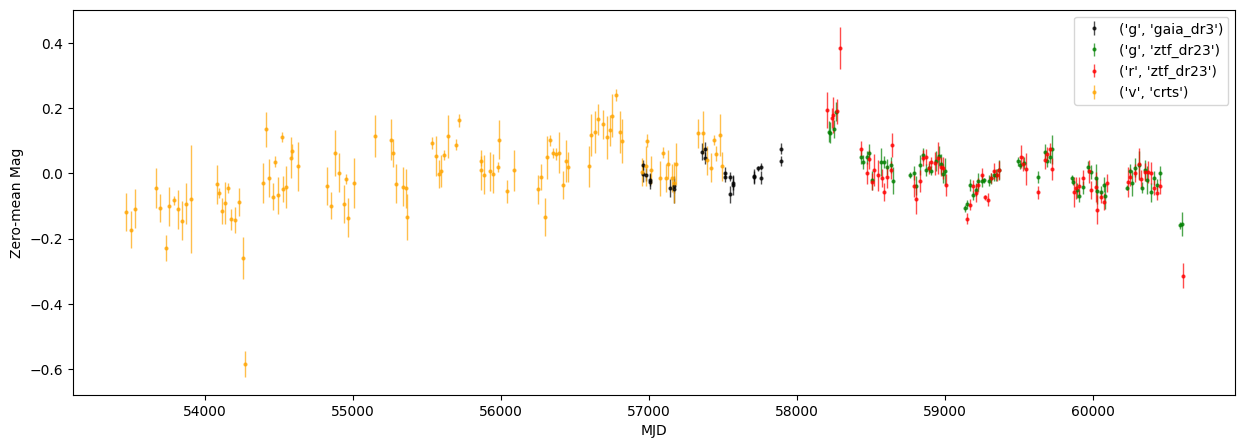

In [27]:
gaia_ztf_crts = pd.concat([gaia_df, ztf_df_binned, crts_df_binned], ignore_index=True)

# Add a zero-mean column
gaia_ztf_crts['mag_zero_mean'] = gaia_ztf_crts.groupby(by=["survey", "band"])['mag'].transform(lambda x: x - x.mean())

fig, ax = plt.subplots(figsize=(15, 5))
for (name, group), color in zip(
    gaia_ztf_crts.groupby(["band", "survey"]), ["black", "green", "red", "orange"]
):
    ax.errorbar(
        group.mjd,
        group.mag_zero_mean,
        yerr=group.mag_error,  # / m,
        marker="o",
        linestyle="",
        ms=2,
        elinewidth=1,
        label=name,
        alpha=0.7,
        color=color,
    )
plt.ylabel("Zero-mean Mag")
plt.xlabel("MJD")
plt.legend(loc="best")
plt.savefig("gaia-crts-ztf-lc.png", dpi=600)

In [28]:
gaia_ztf_crts_nested = npd.NestedFrame.from_flat(
    gaia_ztf_crts,
    base_columns=["id", "ra", "dec"],
    nested_columns=["mjd", "mag", "mag_zero_mean", "mag_error", "band", "survey", "survey_id"],
    name="lc",
    on="id",
).reset_index()

In [29]:
gaia_ztf_crts_nested

id          ra        dec  \
0   0  160.798045  11.397157   

                                                  lc  
0  [{mjd: 56958.447751, mag: 18.374451, mag_zero_...

In [36]:
gaia_ztf_crts_nested.lc.explode()

,mjd,mag,mag_zero_mean,mag_error,band,survey,survey_id
0,56958.447751,18.374451,-0.00097,0.026129,g,gaia_dr3,3870752104863883264
0,56958.521736,18.401174,0.025753,0.016612,g,gaia_dr3,3870752104863883264
...,...,...,...,...,...,...,...
0,57480.168925,18.346007,0.116782,0.06454,v,crts,1112057002374
0,57497.190105,18.251046,0.021821,0.044276,v,crts,1112057002374


In [30]:
gaia_ztf_crts_nested.to_parquet("2509.10601-gaia-ztf-crts.pq")

In [5]:
gaia_ztf_crts_nested = npd.read_parquet("2509.10601-gaia-ztf-crts.pq")
gaia_ztf_crts_nested

id          ra        dec  \
0   0  160.798045  11.397157   

                                                  lc  
0  [{mjd: 56958.447751, mag: 18.374451, mag_zero_...

In [6]:
bands = ["r",'v']
gaia_ztf_crts_nested.query(f"lc.band.isin({bands})")

id          ra        dec  \
0   0  160.798045  11.397157   

                                                  lc  
0  [{mjd: 58202.278498, mag: 18.769539, mag_zero_...

In [7]:
from angst.dataset import DataSet

In [8]:
angst_ds = DataSet(gaia_ztf_crts_nested)
angst_ds.df.head()

id          ra        dec  \
0   0  160.798045  11.397157   

                                                  lc  
0  [{mjd: 56958.447751, mag: 18.374451, mag_zero_...

In [36]:
angst_ds.df.lc.nest.columns

['mjd', 'mag', 'mag_zero_mean', 'mag_error', 'band', 'survey', 'survey_id']

In [38]:
angst_ds.cols

['id',
 'ra',
 'dec',
 'lc',
 'lc.mjd',
 'lc.mag',
 'lc.mag_zero_mean',
 'lc.mag_error',
 'lc.band',
 'lc.survey',
 'lc.survey_id']

In [111]:
bands = ["r", "g"]
angst_ds.get_cols_for_id(0, "lc.mjd", "lc.mag", "lc.mag_error", "lc.survey", "lc.band", bands=bands).explode("lc").groupby(by=["survey", "band"])['mag'].transform(lambda x: x - x.mean())

0    -0.00097
0    0.025753
       ...   
0    -0.15559
0    -0.31447
Name: mag, Length: 169, dtype: double[pyarrow]

In [112]:
from angst import analysis

In [139]:
fspec = analysis.SingleAGNFreeSpectrum(angst_ds, 0, ["r",'v', 'g'], 14 )

<ErrorbarContainer object of 3 artists>

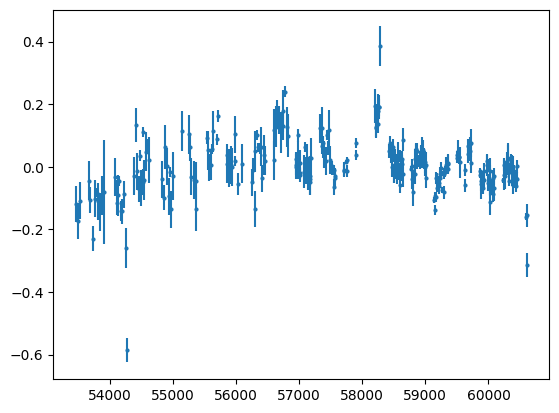

In [140]:
plt.errorbar(fspec.agn_mjd, fspec.agn_lc_zero_mean, fspec.agn_lc_err, ms=2, fmt='o')